### Trasformation 

\begin{equation}
E: (a, e, M, w)  \rightarrow X: (x,y,v_x, v_y)
\end{equation}

\begin{equation}
    \mathbb{J}_{X o E} =
    \begin{pmatrix} 
    \partial_ax & \partial_ex & \partial_wx & \partial_Mx\\
    \partial_ay & \partial_ey & \partial_wy & \partial_My \\
    \partial_av_x & \partial_ev_x & \partial_wv_x & \partial_Mv_x \\
    \partial_av_y & \partial_ev_y & \partial_wv_y & \partial_Mv_y 
    \end{pmatrix}
\end{equation}

In [90]:
import numpy as np
from Utils import CanonicalUnits, calcKeplerianJacobians, JaccobianComponents, Kepler, GravitationalParameters, X2E, computeNumericalJacobian, OrbitTrasformations
import spiceypy as spy
import scipy.optimize as optimize
from tqdm import tqdm
from typing import Dict, Set, Optional, Union, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [91]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

In [92]:
def compute_functions(i: float, w: float, Omega: float, 
                    which: Set[str]) -> Dict[str, float]:
    """Compute transformation functions A, B, C, D, F, G"""
    results = {}
    
    if 'A' in which:
        results['A'] = (np.cos(Omega)*np.cos(w) - np.sin(Omega)*np.cos(i)*np.sin(w))
    if 'B' in which:
        results['B'] = (-np.cos(Omega)*np.sin(w) - np.sin(Omega)*np.cos(i)*np.cos(w))
    if 'C' in which:
        results['C'] = (np.sin(Omega)*np.cos(w) + np.cos(Omega)*np.cos(i)*np.sin(w))
    if 'D' in which:
        results['D'] = (-np.sin(Omega)*np.sin(w) + np.cos(Omega)*np.cos(i)*np.cos(w))
    
    return results

def compute_state_vector(E: np.array, mu: float) -> np.array:
    state_vector = spy.conics(E+[0, mu], 0)
    return state_vector

def jacobian_XoE(a: float, e: float, w: float, M: float, mu: float) -> np.array:
    i = 0
    Omega = 0
    E = optimize.newton(Kepler, M, args=(M, e))

    functions = compute_functions(i, w, Omega, {'A', 'B', 'C', 'D'})
    A = functions['A']
    B = functions['B']
    C = functions['C']
    D = functions['D']
    
    ot = OrbitTrasformations()
    v_r = ot.nu(a, mu)/(2*ot.r(a, e, E)*a)
    r = ot.r(a, e, E)
    eps = ot.sqrt_e(e)
    nu = ot.nu(a, mu)
    nur = nu/r

    q = a*(1-e)
    state_vector = compute_state_vector([q, e, i, Omega, w, M], mu)

    #partial a

    partial_a_x = state_vector[0]/a
    partial_a_y = state_vector[1]/a
    partial_a_vx = -state_vector[3]/(2*a)
    partial_a_vy = -state_vector[4]/(2*a)

    partial_a = [partial_a_x, partial_a_y, partial_a_vx, partial_a_vy]

    #partial e

    #dX/de
    dcosEde=-a*np.sin(E)**2/r       
    dsinEde=a*np.cos(E)*np.sin(E)/r
    dnurde=(nu*a/r**2)*(np.cos(E)-(a/r)*e*np.sin(E)**2)
    depsde=-e/eps

    drAde=a*(dcosEde-1)
    drBde=a*(depsde*np.sin(E)+eps*dsinEde)

    dvAde=-(dnurde*np.sin(E)+nur*dsinEde)
    dvBde=(dnurde*eps*np.cos(E)+nur*depsde*np.cos(E)+nur*eps*dcosEde)

    partial_e = np.array([
        drAde*A+drBde*B,
        drAde*C+drBde*D,
        dvAde*A+dvBde*B,
        dvAde*C+dvBde*D
    ])

    #partial w
    q = a*(1-e)
    state_vector = compute_state_vector([q, e, i, Omega, w, M], mu)

    partial_w_x = -state_vector[1]*np.cos(i) - state_vector[2]*np.sin(i)*np.cos(Omega)
    partial_w_y = state_vector[0]*np.cos(i) - state_vector[2]*np.sin(i)*np.sin(Omega)
    partial_w_vx = -state_vector[4]*np.cos(i) - state_vector[5]*np.sin(i)*np.cos(Omega)
    partial_w_vy = state_vector[3]*np.cos(i) - state_vector[5]*np.sin(i)*np.sin(Omega)

    partial_w = [partial_w_x, partial_w_y, partial_w_vx, partial_w_vy]

    #partial M
    n = (mu/a**3)**0.5
    factor = -(mu*a**3)**0.5/r**3

    partial_M_x = (1/n) * state_vector[3]
    partial_M_y = (1/n) * state_vector[4]
    partial_M_vx = factor * state_vector[0]
    partial_M_vy = factor * state_vector[1]

    partial_M = [partial_M_x, partial_M_y, partial_M_vx, partial_M_vy]

    J = np.zeros((4,4))
    J[:,0] = partial_a
    J[:,1] = partial_e
    J[:,2] = partial_w
    J[:,3] = partial_M
    
    return J


In [93]:
a = 0.5
e = 0.1
i = 0
Omega = 0
w = np.pi/2
M = np.pi
q = a*(1-e)

J = jacobian_XoE(a,e,w,M,mu)

Je2c=np.eye(4)
Je2c[0,0]=1/(1-e)
Je2c[0,1]=q/(1-e)**2
Jq=np.matmul(J,Je2c)
Jq

array([[ 2.34912103e-15,  1.20548516e-15,  5.50000000e-01,
         4.52267017e-01],
       [-1.22222222e+00, -1.11111111e+00,  1.05710446e-15,
         9.25934527e-16],
       [-8.93172099e+00, -1.25856068e+01, -1.64574680e-14,
        -1.41163557e-14],
       [-1.82860756e-14, -6.84694175e-15,  8.03854889e+00,
         7.34458692e+00]])

In [94]:
E = [q, e, 0, 0, w, M]
E2X = lambda E, mu: spy.conics(E+[0, mu], 0)
dX=np.array([1e-3]*6)
args=dict(mu=mu)
E_num, JXoE=computeNumericalJacobian(E2X,E,dX,**args)
JXoE

array([[-1.36877367e-13, -2.72639618e-13,  0.00000000e+00,
         5.49999908e-01,  5.49999908e-01,  4.52266960e-01],
       [-1.22222222e+00, -1.11111248e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -1.11022302e-13],
       [ 0.00000000e+00,  0.00000000e+00, -5.49999908e-01,
         0.00000000e+00,  0.00000000e+00, -0.00000000e+00],
       [-8.93174855e+00, -1.25856115e+01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-3.59016386e-12, -1.79957317e-12,  0.00000000e+00,
         8.03854755e+00,  8.03854755e+00,  7.34458628e+00],
       [-0.00000000e+00,  0.00000000e+00,  5.69401612e-15,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [95]:
Jcomp = np.zeros((4,4))
Jcomp[0,0] = JXoE[0,0]
Jcomp[0,1] = JXoE[0,1]
Jcomp[0,2] = JXoE[0,4]
Jcomp[0,3] = JXoE[0,5]
Jcomp[1,0] = JXoE[1,0]
Jcomp[1,1] = JXoE[1,1]
Jcomp[1,2] = JXoE[1,4]
Jcomp[1,3] = JXoE[1,5]
Jcomp[2,0] = JXoE[3,0]
Jcomp[2,1] = JXoE[3,1]
Jcomp[2,2] = JXoE[3,4]
Jcomp[2,3] = JXoE[3,5]
Jcomp[3,0] = JXoE[4,0]
Jcomp[3,1] = JXoE[4,1]
Jcomp[3,2] = JXoE[4,4]
Jcomp[3,3] = JXoE[4,5]
Jcomp


array([[-1.36877367e-13, -2.72639618e-13,  5.49999908e-01,
         4.52266960e-01],
       [-1.22222222e+00, -1.11111248e+00,  0.00000000e+00,
        -1.11022302e-13],
       [-8.93174855e+00, -1.25856115e+01,  0.00000000e+00,
         0.00000000e+00],
       [-3.59016386e-12, -1.79957317e-12,  8.03854755e+00,
         7.34458628e+00]])

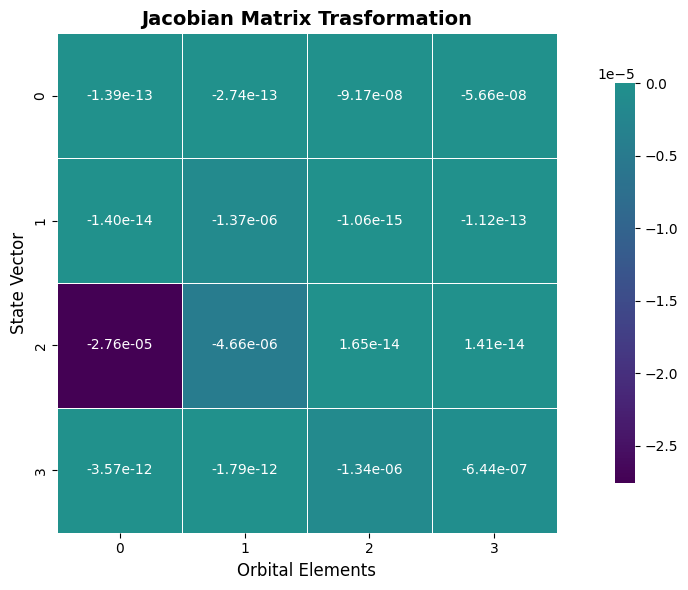

In [96]:
plt.figure(figsize=(12, 6))

# Create heatmap
sns.heatmap(Jcomp - Jq, 
            annot=True, 
            fmt='.2e', 
            cmap='viridis', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title(f'Jacobian Matrix Trasformation', fontsize=14, fontweight='bold')
plt.xlabel('Orbital Elements', fontsize=12)
plt.ylabel('State Vector', fontsize=12)
plt.tight_layout()
plt.show()

In [97]:
def jacobian_EoX_num(q: float, e: float, w: float, M: float, mu: float) -> np.array:
    E = [q, e, 0, 0, w, M]
    X = spy.conics(E+[0, mu], 0)
    dX=np.array([1e-3]*6)
    args=dict(mu=mu)
    E_num, JEoX=computeNumericalJacobian(X2E,X,dX,**args)

    partial_xq = JEoX[0,0]
    partial_xe = JEoX[1,0]
    partial_xw = JEoX[4,0]
    partial_xM = JEoX[5,0]

    partial_yq = JEoX[0,1]
    partial_ye = JEoX[1,1]
    partial_yw = JEoX[4,1]
    partial_yM = JEoX[5,1]

    partial_vxq = JEoX[0,3]
    partial_vxe = JEoX[1,3]
    partial_vxw = JEoX[4,3]
    partial_vxM = JEoX[5,3]

    partial_vyq = JEoX[0,4]
    partial_vye = JEoX[1,4]
    partial_vyw = JEoX[4,4]
    partial_vyM = JEoX[5,4]

    Matrix = np.array([[partial_xq, partial_yq, partial_vxq, partial_vyq], 
                        [partial_xe, partial_ye, partial_vxe, partial_vye], 
                        [partial_xw, partial_yw, partial_vxw, partial_vyw], 
                        [partial_xM, partial_yM, partial_vxM, partial_vyM]])
    return Matrix


In [98]:
def trasformation_aewE_to_xyvxvy(a: float, e: float, w: float, M: float, mu: float) -> tuple[float, float, float, float]:
    Omega = 0
    i = 0
    q = a*(1-e)

    state_vec = compute_state_vector([q, e, i, Omega, w, M], mu)
    x = state_vec[0]
    y = state_vec[1]
    vx = state_vec[3]
    vy = state_vec[4]

    return x, y, vx, vy

def trasformation_xyvxvy_to_aewE(x: float, y: float, vx: float, vy: float, mu: float) -> tuple[float, float, float, float]:

    elements = spy.oscelt([x, y, 0, vx, vy, 0], et=0, mu=mu)
    q = elements[0]
    e = elements[1]
    w = elements[4]
    M = elements[5]
    a = q/(1-e)

    return a, e, w, M

In [99]:
N = int(1e5)

a_uniform = np.random.uniform(0, 2, N)
e_uniform = np.random.uniform(0, 1, N)
w_uniform = np.random.uniform(0, 2*np.pi, N)
M_uniform = np.random.uniform(0, 2*np.pi, N)
q_uniform = a_uniform*(1-e_uniform)

x_uniform, y_uniform, vx_uniform, vy_uniform = trasformation_aewE_to_xyvxvy(a_uniform[0], e_uniform[0], w_uniform[0], M_uniform[0], mu)
x_uniform, y_uniform, vx_uniform, vy_uniform

(1.3403432042933623,
 -1.5289099203839371,
 3.5477938621344114,
 1.9738744722771928)

In [100]:
a_inverse, e_inverse, w_inverse, M_inverse = trasformation_xyvxvy_to_aewE(x_uniform, y_uniform, vx_uniform, vy_uniform, mu)
a_inverse, e_inverse, w_inverse, M_inverse 

(1.7660333646548774,
 0.25724811413604703,
 3.0367099875710553,
 1.9915472167654764)

In [101]:
jacobian_XoE(q_uniform[1], e_uniform[1], w_uniform[1], M_uniform[1], mu)

array([[ 1.17100714,  0.37067709,  0.02202138,  0.07221795],
       [-0.05245804,  0.51181125,  0.49157755,  0.34530787],
       [-1.98733775, -5.05307794, -7.97802658, -7.05174189],
       [-9.50239299, -6.04479511,  1.66853059,  0.31589948]])

In [102]:
xyvxvy = np.zeros((N, 4))

for el in tqdm(range(N)):
    a = a_uniform[el]
    e = e_uniform[el]
    w = w_uniform[el]
    M = M_uniform[el]

    x, y, vx, vy = trasformation_aewE_to_xyvxvy(a, e, w, M, mu)
    xyvxvy[el] = np.array([x, y, vx, vy])

100%|██████████| 100000/100000 [00:00<00:00, 106977.74it/s]


In [103]:
xyvxvy

array([[ 1.34034320e+00, -1.52890992e+00,  3.54779386e+00,
         1.97387447e+00],
       [ 6.41656513e-01, -2.87445237e-02,  1.46042376e+00,
         6.98297029e+00],
       [-7.44556184e-01,  2.82699756e+00, -2.04751114e+00,
        -9.02403839e-01],
       ...,
       [ 3.90357952e-03, -7.25200292e-04,  2.95977567e+01,
         6.28342553e+01],
       [-1.15473295e+00, -7.49505724e-01,  2.72986827e+00,
        -4.91013347e+00],
       [-7.08823765e-02, -3.09909439e-02,  1.15531197e+01,
        -2.53620496e+01]])

In [104]:
def P_aewM() -> float:
    a_max = 2; a_min = 0
    e_max = 1; e_min = 0
    w_max = 2*np.pi; w_min = 0
    M_max = 2*np.pi; M_min = 0
    return 1/(a_max - a_min) * 1/(e_max - e_min) * 1/(w_max - w_min) * 1/(M_max - M_min)

def P_xyvxvy(x: float, y: float, vx: float, vy: float) -> float:
    a, e, w, M = trasformation_xyvxvy_to_aewE(x, y, vx, vy, mu)
    J = jacobian_XoE(a,e,w,M,mu)
    #det = np.linalg.det(J)
    det = 1.0/np.linalg.det(J)
    P = P_aewM() * abs(det)
    return P

def P_xyvxvy_vectorized(x: np.array, y: np.array, vx: np.array, vy: np.array) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    vx = np.asarray(vx)
    vy = np.asarray(vy)

    # Prepare output array
    shape = np.broadcast(x, y, vx, vy).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()

    for idx in range(x_flat.size):
        a, e, w, M = trasformation_xyvxvy_to_aewE(x_flat[idx], y_flat[idx], vx_flat[idx], vy_flat[idx], mu)
        J = jacobian_XoE(a,e,w,M,mu)
        #det = np.linalg.det(J)/(1-e)
        det = 1.0/np.linalg.det(J)
        P.flat[idx] = P_aewM() * abs(det)

    return P.reshape(shape)


## Probabilidad en un hipercubo

In [105]:
def surface_integral_P_xyvxvy(center, widths, n_points=8):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, vx0, vy0 = center
    dx, dy, dvx, dvy = widths

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts

    # Create meshgrid of all quadrature points
    X, Y, VX, VY = np.meshgrid(x_pts, y_pts, vx_pts, vy_pts, indexing='ij')
    WX, WY, WVX, WVY = np.meshgrid(wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    WF = (WX * WY * WVX * WVY).ravel()

    # Evaluate P at all points
    Pf = P_xyvxvy_vectorized(Xf, Yf, VXf, VYf)

    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dvx) * (0.5*dvy)
    return integral

In [106]:
# Example: Compare theoretical (integral) and numerical (count) number of objects in a phase-space volume

# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 0
v_x = 0
v_y = (mu/1)**0.5

dxy = 0.5
dvxy = 5000 * (1/AU_m) * year

center = (c_x, c_y, v_x, v_y)
widths = (dxy, dxy, dvxy, dvxy)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = surface_integral_P_xyvxvy(center, widths, n_points=8)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

# Numerical: count number of objects in the volume from the sample
objsx = (abs(xyvxvy[:,0] - c_x) <= dxy/2) 
objsy = (abs(xyvxvy[:,1] - c_y) <= dxy/2) 
objsvx = (abs(xyvxvy[:,2] - v_x) <= dvxy/2) 
objsvy = (abs(xyvxvy[:,3] - v_y) <= dvxy/2) 

objects = objsx & objsy & objsvx & objsvy
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')

Theoretical (integral) number of objects in volume: 117.75825215646434
Numerical (count) number of objects inside volume: 121


In [77]:
(N_theoretical * N)/N_numeric

78.7175437678075

## Probabilidad en circulo para x,y y cuadrado para vx, vy

In [14]:
def integral_P_xyvxvy_circle_box(center_xy, r, center_vxvy, dvx, dvy, n_points_r=8, n_points_theta=16, n_points_vx=8, n_points_vy=8):
    """
    Computes the integral of P_xyvxvy in a circle for x, y (center center_xy, radius r)
    and in a box for vx, vy (center center_vxvy, dimensions dvx, dvy).
    Uses Gauss quadrature for the surface integral in (x, y) and midpoint rule for (vx, vy).

    Parameters:
        center_xy: tuple (x0, y0) - center of the circle in x, y
        r: float - radius of the circle in x, y
        center_vxvy: tuple (vx0, vy0) - center of the box in vx, vy
        dvx: float - width of the box in vx
        dvy: float - width of the box in vy
        n_points_r: int - number of Gauss points in radial direction (for x, y)
        n_points_theta: int - number of Gauss points in angular direction (for x, y)
        n_points_vx: int - number of points in vx
        n_points_vy: int - number of points in vy

    Returns:
        float: The integral value
    """

    x0, y0 = center_xy
    vx0, vy0 = center_vxvy

    # Gauss-Legendre quadrature for r in [0, r]
    r_nodes, r_weights = np.polynomial.legendre.leggauss(n_points_r)
    r_grid = 0.5 * r * (r_nodes + 1)  # map from [-1,1] to [0, r]
    r_w = 0.5 * r * r_weights         # scale weights

    # Gauss-Legendre quadrature for theta in [0, 2pi]
    theta_nodes, theta_weights = np.polynomial.legendre.leggauss(n_points_theta)
    theta_grid = np.pi * (theta_nodes + 1)  # map from [-1,1] to [0, 2pi]
    theta_w = np.pi * theta_weights         # scale weights

    # Meshgrid for r and theta
    rr, tt = np.meshgrid(r_grid, theta_grid, indexing='ij')
    wr, wt = np.meshgrid(r_w, theta_w, indexing='ij')
    xx = x0 + rr * np.cos(tt)
    yy = y0 + rr * np.sin(tt)
    jac_xy = rr  # Jacobian for polar to cartesian

    # Combine weights for (r, theta)
    w_xy = (wr * wt * jac_xy).ravel()
    xx_flat = xx.ravel()
    yy_flat = yy.ravel()
    n_xy = xx_flat.size

    # Midpoint rule for vx, vy in box
    vx_grid = np.linspace(vx0 - dvx/2 + dvx/(2*n_points_vx), vx0 + dvx/2 - dvx/(2*n_points_vx), n_points_vx)
    vy_grid = np.linspace(vy0 - dvy/2 + dvy/(2*n_points_vy), vy0 + dvy/2 - dvy/(2*n_points_vy), n_points_vy)
    dvx_step = dvx / n_points_vx
    dvy_step = dvy / n_points_vy

    vx_flat = np.repeat(vx_grid, n_points_vy)
    vy_flat = np.tile(vy_grid, n_points_vx)
    n_v = vx_flat.size

    # Broadcast to all combinations
    XX = np.repeat(xx_flat, n_v)
    YY = np.repeat(yy_flat, n_v)
    W_XY = np.repeat(w_xy, n_v)
    VX = np.tile(vx_flat, n_xy)
    VY = np.tile(vy_flat, n_xy)

    # Evaluate P at all points
    P_vals = P_xyvxvy_vectorized(XX, YY, VX, VY)

    # The volume element: Gauss weights for (x, y), midpoint for (vx, vy)
    dV = W_XY * dvx_step * dvy_step

    # Integral is sum(P * dV)
    integral = np.sum(P_vals * dV)
    return integral

In [15]:
c_x = 1
c_y = 0
v_x = 0
v_y = (mu/1)**0.5

dxy = 0.5
dvxy = 5000 * (1/AU_m) * year

center_xy = (c_x, c_y)
center_vxvy = (v_x, v_y)
widths_xy = (dxy, dxy)
widths_vxvy = (dvxy, dvxy)

r_circle = 2

# Count objects inside the circle in (x, y), all velocities
mask_circle = (xyvxvy[:,0] - c_x)**2 + (xyvxvy[:,1] - c_y)**2 <= r_circle**2
count_in_circle = np.sum(mask_circle)

# Count objects inside the box in (vx, vy), all positions
mask_box = (
    (xyvxvy[:,2] >= v_x - dvxy/2) & (xyvxvy[:,2] <= v_x + dvxy/2) &
    (xyvxvy[:,3] >= v_y - dvxy/2) & (xyvxvy[:,3] <= v_y + dvxy/2)
)
count_in_box = np.sum(mask_box)

# Count objects inside both the circle and the box
mask_both = mask_circle & mask_box
count_in_both = np.sum(mask_both)


# Use the provided function to calculate the theoretical integral
# integral_P_xyvxvy_circle_box should be defined elsewhere in the notebook

prob_int_both = integral_P_xyvxvy_circle_box(
    center_xy, r_circle, center_vxvy, dvxy, dvxy,
    n_points_r=20, n_points_theta=40, n_points_vx=40, n_points_vy=40
)

print("Numerical experiment (fraction of samples):")
print(f"  In both circle (x, y) and box (vx, vy): {count_in_both}")

print("\nIntegral of P_xyvxvy over regions (using integral_P_xyvxvy_circle_box):")
print(f"  In both: {prob_int_both * N}")

C:\Users\aguju\AppData\Local\Temp\ipykernel_22552\1534952615.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  a = q/(1-e)
C:\Users\aguju\AppData\Local\Temp\ipykernel_22552\1096567449.py:38: RuntimeWarning: invalid value encountered in scalar multiply
  q = a*(1-e)
c:\Users\aguju\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\linalg\linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Numerical experiment (fraction of samples):
  In both circle (x, y) and box (vx, vy): 302

Integral of P_xyvxvy over regions (using integral_P_xyvxvy_circle_box):
  In both: nan


## Probabilidad en circulo en x, y, pero en todas las velocidades 

In [20]:
def surface_integral_P_xyvxvy_circle_allv(center_xy, r, n_points_r=20, n_points_theta=40, n_points_v=20, v_lim=8):
    """
    Compute the surface integral of P_xyvxvy over a circle in (x, y) of radius r centered at center_xy,
    and over all velocities (vx, vy) from -inf to inf (approximated by [-v_lim, v_lim]).
    Uses Gauss-Legendre quadrature for all variables and the vectorized P_xyvxvy.
    """
    x0, y0 = center_xy

    # Gauss-Legendre nodes and weights for r in [0, r]
    r_nodes, r_weights = np.polynomial.legendre.leggauss(n_points_r)
    r_nodes = 0.5 * (r_nodes + 1) * r  # map from [-1,1] to [0, r]
    r_weights = 0.5 * r * r_weights

    # Gauss-Legendre nodes and weights for theta in [0, 2pi]
    theta_nodes, theta_weights = np.polynomial.legendre.leggauss(n_points_theta)
    theta_nodes = 0.5 * (theta_nodes + 1) * 2 * np.pi
    theta_weights = 0.5 * 2 * np.pi * theta_weights

    # Gauss-Legendre nodes and weights for vx, vy in [-v_lim, v_lim]
    vx_nodes, vx_weights = np.polynomial.legendre.leggauss(n_points_v)
    vx_nodes = 0.5 * (vx_nodes + 1) * 2 * v_lim - v_lim
    vx_weights = 0.5 * 2 * v_lim * vx_weights

    vy_nodes, vy_weights = np.polynomial.legendre.leggauss(n_points_v)
    vy_nodes = 0.5 * (vy_nodes + 1) * 2 * v_lim - v_lim
    vy_weights = 0.5 * 2 * v_lim * vy_weights

    # Create meshgrid for all variables
    rr, tt, vvx, vvy = np.meshgrid(r_nodes, theta_nodes, vx_nodes, vy_nodes, indexing='ij')
    rr_w, tt_w, vvx_w, vvy_w = np.meshgrid(r_weights, theta_weights, vx_weights, vy_weights, indexing='ij')

    # Convert polar to cartesian for x, y
    xx = x0 + rr * np.cos(tt)
    yy = y0 + rr * np.sin(tt)

    # Compute the full weight for each point
    weights = rr_w * tt_w * vvx_w * vvy_w * rr  # extra rr for Jacobian of polar coords

    # Evaluate the probability density at all points
    P_vals = P_xyvxvy_vectorized(xx, yy, vvx, vvy)

    # Surface integral
    integral = np.sum(P_vals * weights)
    return integral

In [21]:
c_x = 1
c_y = 0
center_xy = (c_x, c_y)
r_circle = 2

# Count objects inside the circle in (x, y), all velocities
mask_circle = (xyvxvy[:,0] - c_x)**2 + (xyvxvy[:,1] - c_y)**2 <= r_circle**2
count_in_circle = np.sum(mask_circle)

# Use the provided function to calculate the theoretical integral
# integral_P_xyvxvy_circle_box should be defined elsewhere in the notebook

prob_int_both = surface_integral_P_xyvxvy_circle_allv(
    center_xy, r_circle
)

print("Numerical experiment (fraction of samples):")
print(f"  In circle (x, y): {count_in_circle}")

print("\nIntegral of P_xyvxvy over regions (using integral_P_xyvxvy_circle_box):")
print(f"  In both: {prob_int_both * N}")

Numerical experiment (fraction of samples):
  In circle (x, y): 74700

Integral of P_xyvxvy over regions (using integral_P_xyvxvy_circle_box):
  In both: 691173664305521.9


## Probabilidad en hiperesfera 